# Introduction

Two-sample Mendelian Randomization (MR) is a powerful statistical method used to infer causal relationships between risk factors and health outcomes using genetic data. In this approach, genetic variants associated with an exposure (such as cholesterol levels) are used as instruments to assess their effect on an outcome (like heart disease) in separate, independent samples. By leveraging genetic variants, which are randomly allocated and less influenced by confounding factors, two-sample MR provides a robust way to estimate causal effects and avoid some of the biases present in traditional observational studies.

This method involves obtaining summary statistics from two distinct datasets: one for the exposure and one for the outcome. By combining these datasets, researchers can estimate the causal effect of the exposure on the outcome with increased statistical power and precision. Two-sample MR is widely used in public health and biostatistics to provide insights into how modifiable risk factors impact health outcomes, guiding more effective prevention and treatment strategies.

In this notebook you will perform a two-sample Mendelian Randomization study. We will apply MR-IVW (Inverse-Variance Weighted) and MR-Egger on a toy dataset to estimate causal effects. MR-IVW combines multiple genetic instruments by weighting them according to their precision, assuming all instruments are valid. In contrast, MR-Egger Regression allows for potential pleiotropy (where instruments affect the outcome through pathways other than the exposure) by including an intercept term to adjust for directional pleiotropy, providing a more flexible approach when there are concerns about instrument validity. At the end there is a bonus question to run five main MR methods all together on the simulated data and analyze the results.

# Load and preprocess the data

First please load the data in `../data/MR_genotype_data_with_missing.csv` and `../data/MR_phenotype_data_with_missing.csv` and name them `genotype_data` and `phenotype_data`. Keep the names same before and after the imputation.

In [53]:
library(tidyverse)

In [54]:
genotype_data = read.csv('../data/MR_genotype_data_with_missing.csv')
phenotype_data = read.csv('../data/MR_phenotype_data_with_missing.csv')

***

**Question 1: analyze the pattern of missing data in the phenotype dataset. Are there any specific patterns (e.g., missingness concentrated in certain columns or rows)?**

**Answer:** In 1000 observations, there are thirty missing values in the exposure column and twenty missing values in the outcome column. There are no alternate encodings for missing data. There are no missing values in any other column. No observation has both exposure and outcome values missing. From a simple test, we can conclude that there is no relationship in missing values between sex, outcome, and exposure. 

In [55]:
# how many rows
nrow(phenotype_data)

[1] 1000

In [56]:
# look at missing data by column
phenotype_data |>
    is.na() |>
    colSums()

Individual_ID      Exposure       Outcome           Age           Sex 
            0            30            20             0             0

In [57]:
# a glance at the age data shows that there are no 
# outliers coded as missing data e.g. -1 or 999
summary(phenotype_data)

 Individual_ID       Exposure          Outcome            Age       
 Min.   :   1.0   Min.   :-0.6112   Min.   :0.9027   Min.   :19.59  
 1st Qu.: 250.8   1st Qu.: 2.2827   1st Qu.:3.4337   1st Qu.:42.95  
 Median : 500.5   Median : 3.0402   Median :4.2037   Median :49.43  
 Mean   : 500.5   Mean   : 3.0274   Mean   :4.2127   Mean   :49.65  
 3rd Qu.: 750.2   3rd Qu.: 3.7557   3rd Qu.:4.9467   3rd Qu.:56.64  
 Max.   :1000.0   Max.   : 6.8861   Max.   :8.3812   Max.   :78.32  
                  NA's   :30        NA's   :20                      
     Sex           
 Length:1000       
 Class :character  
 Mode  :character  
                   
                   
                   
                   

In [58]:
# a glance at the sex data shows that there is no unexpected encodings e.g. "Uknown"
table(phenotype_data$Sex)


Female   Male 
   472    528 

In [59]:
# count missing data
phenotype_missing = 
    phenotype_data |>
    mutate(missing_vals = rowSums(is.na(phenotype_data)))

phenotype_missing |>
    pull(missing_vals)|>
    table()


  0   1 
950  50 

In [60]:
# compare missing values to sex
summary(lm( missing_vals ~ Sex, data = phenotype_missing))


Call:
lm(formula = missing_vals ~ Sex, data = phenotype_missing)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.05508 -0.05508 -0.04545 -0.04545  0.95455 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.05509    0.01004   5.487 5.19e-08 ***
SexMale     -0.00963    0.01382  -0.697    0.486    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.2181 on 998 degrees of freedom
Multiple R-squared:  0.0004866,	Adjusted R-squared:  -0.0005149 
F-statistic: 0.4858 on 1 and 998 DF,  p-value: 0.486


In [61]:
# compare missing exposure to sex and outcome
phenotype_data|>
    mutate(missing_exposure = is.na(phenotype_data$Exposure))|>
    filter(!is.na(phenotype_data$Outcome))|> # drop missing outcome data in order to make the comparison
    lm(formula = missing_exposure ~ Sex + Outcome)|>
    summary()


Call:
lm(formula = missing_exposure ~ Sex + Outcome, data = filter(mutate(phenotype_data, 
    missing_exposure = is.na(phenotype_data$Exposure)), !is.na(phenotype_data$Outcome)))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.06838 -0.03882 -0.03068 -0.02112  0.99026 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.076916   0.022037   3.490 0.000504 ***
SexMale     -0.012221   0.011016  -1.109 0.267572    
Outcome     -0.009461   0.004833  -1.958 0.050551 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1721 on 977 degrees of freedom
Multiple R-squared:  0.005028,	Adjusted R-squared:  0.002991 
F-statistic: 2.468 on 2 and 977 DF,  p-value: 0.08524


In [62]:
# compare missing outcome to sex and exposure
phenotype_data|>
    mutate(missing_exposure = is.na(phenotype_data$Outcome))|>
    filter(!is.na(phenotype_data$Exposure))|> # drop missing exposure data in order to make the comparison
    lm(formula = missing_exposure ~ Sex + Exposure)|>
    summary()


Call:
lm(formula = missing_exposure ~ Sex + Exposure, data = filter(mutate(phenotype_data, 
    missing_exposure = is.na(phenotype_data$Outcome)), !is.na(phenotype_data$Exposure)))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.03086 -0.02276 -0.02044 -0.01815  0.98231 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept) 0.010886   0.014338   0.759    0.448
SexMale     0.001792   0.009160   0.196    0.845
Exposure    0.002901   0.004139   0.701    0.484

Residual standard error: 0.1423 on 967 degrees of freedom
Multiple R-squared:  0.0005383,	Adjusted R-squared:  -0.001529 
F-statistic: 0.2604 on 2 and 967 DF,  p-value: 0.7708


***

**Question 2: given the missingness of data, please perform mode imputation for the genotype data and mean imputation for the phenotype data. Report what is the average age after imputation?**

**Answer:** The missing phenotype data may be imputed with the column mean by applying the function below over the entire data frame, since there are no missing values in the ID, Age, or Sex column, this code will only impute the mean in the correct columns, namely `Exposure` and `Outcome`. Caution should be taken in applying this code to other data that has not been vetted. The average age before and after imputation is 49.65. 

The missing genotype data may be imputed in a similar way, except with the mode (most common) occurrence in each column instead of the mean. I imagine this is because the columns give counts of the number of copies of an allele, of which a person may have zero, one, or two. Therefore, the data structure would not allow non-integer values outside these bounds. Therefore the mode is most appropriate. 

***

In [63]:
# average age before imputation
round(mean(phenotype_data$Age), 2)

[1] 49.65

In [64]:
phenotype_data = 
    as.data.frame(
        lapply(phenotype_data
               , function(x) ifelse(is.na(x), mean(x, na.rm = TRUE), x)
               )
            )

In [65]:
# average age after mean imputation
round(mean(phenotype_data$Age), 2)

[1] 49.65

In [46]:
nrow(genotype_data)

[1] 1000

In [66]:

# Mode function
get_mode <- function(x) {
  uniq_vals <- unique(na.omit(x))
  freq_vals <- tabulate(match(x, uniq_vals))
  uniq_vals[which.max(freq_vals)]
}

genotype_data = 
    as.data.frame(
        lapply(
            genotype_data, function(x) ifelse(is.na(x), get_mode(x), x)
            ))

# Instrument selection

Now we can use the genotype data to calculate SNP-exposure associations (i.e., estimate the beta values for SNPs). Basically you can do a linear regression between the exposure and each variant and collect the coefficients:

In [74]:
snp_exposure_results <- data.frame(SNP = colnames(genotype_data)[-1],
                                    Beta = numeric(ncol(genotype_data) - 1),
                                    SE = numeric(ncol(genotype_data) - 1),
                                    Pval = numeric(ncol(genotype_data) - 1))

for (snp in colnames(genotype_data)[-1]) {
  genotype <- genotype_data[[snp]]
  exposure <- phenotype_data$Exposure
  fit <- lm(exposure ~ genotype)
  snp_exposure_results$Beta[snp_exposure_results$SNP == snp] <- coef(fit)[2]
  snp_exposure_results$SE[snp_exposure_results$SNP == snp] <- summary(fit)$coefficients[2, 2]
  snp_exposure_results$Pval[snp_exposure_results$SNP == snp] <- summary(fit)$coefficients[2, 4]
}

***

**Question 3: please only select the variants with p-value smaller than 0.01. How many are there?**

**Answer:** By editting the code above, we can save the p-value of the estimated coefficent for each fitted linear regression. We may then filter for the variants with a p-value of less than 0.01. There are 16 of these variants

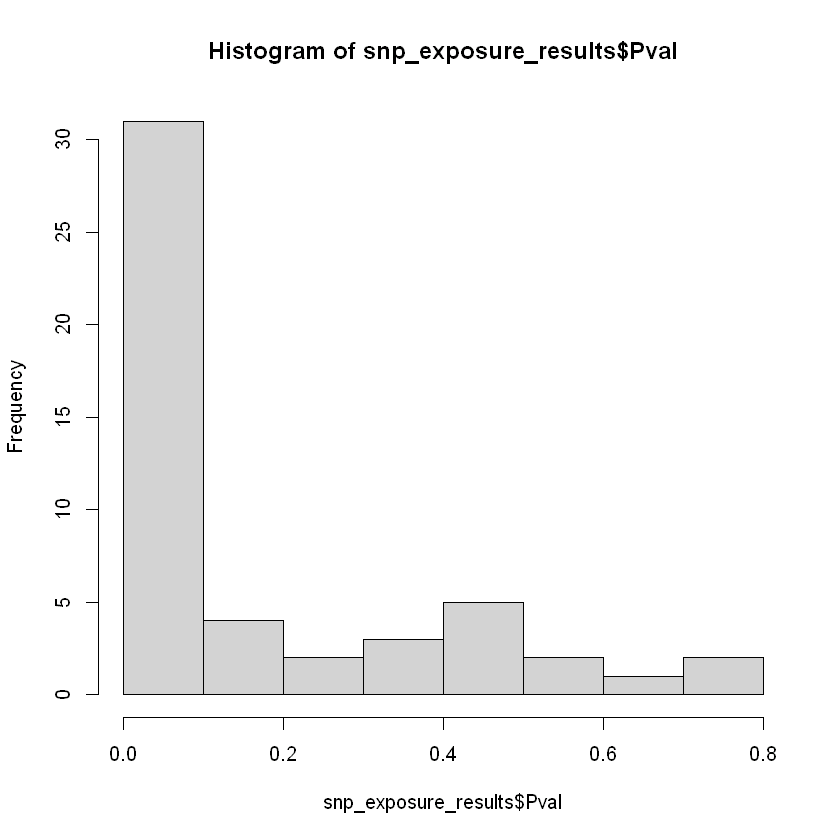

In [78]:
hist(snp_exposure_results$Pval)

In [77]:
# counting variants w small pvals
snp_exposure_results|>
    filter(Pval < 0.01)|>
    nrow()

[1] 16

In [76]:
snp_exposure_results|>
    filter(Pval < 0.01)

SNP,Beta,SE,Pval
<chr>,<dbl>,<dbl>,<dbl>
rs3,0.1754610,0.05278291,9.189746e-04
rs4,0.1561571,0.05205576,2.768607e-03
rs6,0.1383730,0.05353437,9.885924e-03
rs9,0.1412628,0.05407474,9.127001e-03
rs12,0.1441596,0.05371351,7.398237e-03
rs14,0.1837873,0.05530803,9.229732e-04
rs18,0.1566554,0.05282348,3.092438e-03
rs20,0.2262862,0.05377981,2.812852e-05
rs26,0.2126447,0.05254691,5.594403e-05


***

# SNP-outcome association

***

**Question 4: please run the association analysis between variants and the outcome.**

**Answer:** Reusing the same code with a different variable, we may run the same procdedure to conduct associaton analysis between the variants and the outcome. There are 15 variants with a p-value below 0.01. 

In [80]:
snp_outcome_results <- data.frame(SNP = colnames(genotype_data)[-1],
                                    Beta = numeric(ncol(genotype_data) - 1),
                                    SE = numeric(ncol(genotype_data) - 1),
                                    Pval = numeric(ncol(genotype_data) - 1))

for (snp in colnames(genotype_data)[-1]) {
  genotype <- genotype_data[[snp]]
  outcome <- phenotype_data$Outcome
  fit <- lm(outcome ~ genotype)
  snp_outcome_results$Beta[snp_outcome_results$SNP == snp] <- coef(fit)[2]
  snp_outcome_results$SE[snp_outcome_results$SNP == snp] <- summary(fit)$coefficients[2, 2]
  snp_outcome_results$Pval[snp_outcome_results$SNP == snp] <- summary(fit)$coefficients[2, 4]
}

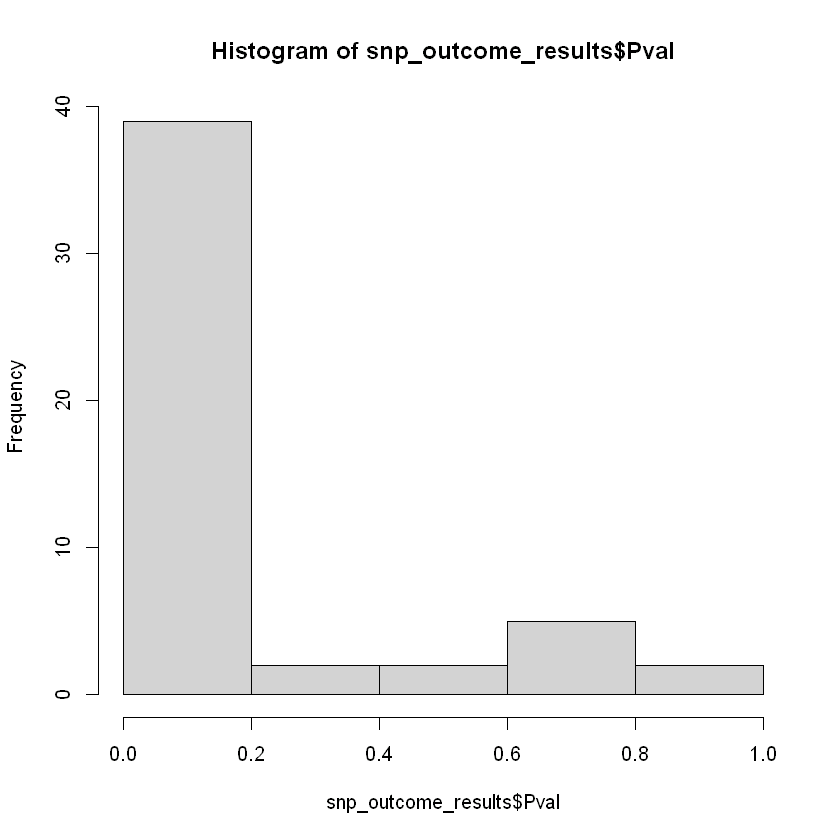

In [82]:
hist(snp_outcome_results$Pval)

In [84]:
# counting variants w small pvals
snp_outcome_results|>
    filter(Pval < 0.01)|>
    nrow()

[1] 15

In [85]:
# counting variants w small pvals
snp_outcome_results|>
    filter(Pval < 0.01)

SNP,Beta,SE,Pval
<chr>,<dbl>,<dbl>,<dbl>
rs2,0.4295070,0.05416528,5.865446e-15
rs3,0.1995445,0.05460931,2.715885e-04
rs4,0.1621254,0.05391724,2.705095e-03
rs8,0.1646770,0.05561988,3.141438e-03
rs10,0.4814048,0.05440493,3.963061e-18
rs14,0.1567184,0.05738907,6.429316e-03
rs15,0.4876392,0.05349528,4.195188e-19
rs16,0.3676765,0.05576496,6.958787e-11
rs19,0.1456230,0.05619870,9.703290e-03


***

# Run two-sample MR

Noe we are ready to run the two-sample MR analysis. Here we can use a R package called [`MendelianRandomization` on CRAN](https://cran.r-project.org/web/packages/MendelianRandomization/index.html).

In [86]:
# Install MendelianRandomization package if not already installed
if (!requireNamespace("MendelianRandomization", quietly = TRUE)) {
  install.packages("MendelianRandomization")
}

# Load the package
library(MendelianRandomization)

Installing package into 'C:/Users/Wayne Monical/Documents/R/win-library/4.1'
(as 'lib' is unspecified)

also installing the dependencies 'DEoptimR', 'gmp', 'arrangements', 'plotly', 'robustbase', 'iterpc', 'rjson'





  There are binary versions available but the source versions are later:
                       binary   source needs_compilation
DEoptimR               1.0-12  1.1-3-1             FALSE
gmp                     0.7-1    0.7-5              TRUE
plotly                 4.10.1   4.10.4             FALSE
robustbase             0.95-1 0.99-4-1              TRUE
rjson                  0.2.21   0.2.23              TRUE
MendelianRandomization  0.7.0   0.10.0              TRUE

  Binaries will be installed
package 'gmp' successfully unpacked and MD5 sums checked
package 'arrangements' successfully unpacked and MD5 sums checked
package 'robustbase' successfully unpacked and MD5 sums checked
package 'iterpc' successfully unpacked and MD5 sums checked
package 'rjson' successfully unpacked and MD5 sums checked
package 'MendelianRandomization' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Wayne Monical\AppData\Local\Temp\RtmpKQbfbv\downloaded_packages


installing the source packages 'DEoptimR', 'plotly'


Warning message:
"package 'MendelianRandomization' was built under R version 4.1.3"


In the vignette [here](https://cran.r-project.org/web/packages/MendelianRandomization/vignettes/Vignette_MR.pdf), please learn how to apply two basic MR methods -- MR-IVW amd MR-Egger. 

**Hint: the input for `mr_ivw` function consists of four components: coefficients and standard errors between variants and exposures, and between variants and outcome. Same for `mr_egger`. Check page 4 and 6 on the vignette PDF.**

***

**Question 5: please run the MR-IVW and MR-Egger analysis.**

**Answer:**

***

# Analyze the results

***

**Question 6: Using the MR-IVW and MR-Egger methods, report the estimated causal effect of the exposure on the outcome, along with standard errors, 95% confidence intervals, and p-values. Compare the estimates from MR-IVW and MR-Egger. What are the key differences between the two methods in your results?**

**Answer:**

***

**Question 7 (optional): Run all the primary Mendelian Randomization methods using the `mr_allmethods` function from the package (use the code below). Visualize the results with the `mr_plot` function. Based on your findings, provide an analysis of the results and discuss the reasons for any observed patterns or outcomes.**

```R
res = mr_allmethods(mr_input(bx=merged_results$Beta_exposure, bxse=merged_results$SE_exposure, 
                               by=merged_results$Beta_outcome, byse=merged_results$SE_outcome), method = "main")
```
